<a href="https://colab.research.google.com/github/Maestria-IA-Aplicada-2025/semana-4/blob/main/Clasificacion_imagenes_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importar las librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# Definir las transformaciones que se aplicarán a las imágenes
transform = transforms.Compose([
    transforms.ToTensor(),               # Convertir las imágenes a tensores
    transforms.Normalize((0.5,), (0.5,))  # Normalizar las imágenes
])

In [3]:
# Cargar el conjunto de datos MNIST
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 606kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.18MB/s]


In [4]:
# Crear los cargadores de datos para entrenamiento y prueba
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

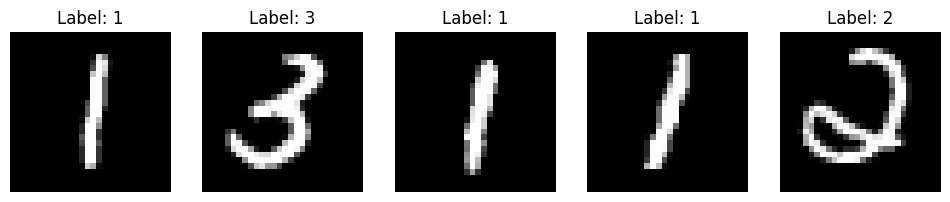

In [5]:
# Visualizar algunas imágenes del conjunto de entrenamiento
data_iter = iter(train_loader)
images, labels = next(data_iter)
# Mostrar las primeras 5 imágenes
fig, axes = plt.subplots(1, 5, figsize=(12, 6))
for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.show()

In [6]:
# Definir la red neuronal
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # Definir las capas de la red
        self.fc1 = nn.Linear(28*28, 128)  # Capa de entrada, imagen de 28x28 a 128 neuronas
        self.fc2 = nn.Linear(128, 64)     # Capa oculta
        self.fc3 = nn.Linear(64, 10)      # Capa de salida, 10 clases (dígitos 0-9)
        self.relu = nn.ReLU()             # Función de activación ReLU

    def forward(self, x):
        x = x.view(-1, 28*28)  # Aplanar la imagen de 28x28 a un vector de 784
        x = self.fc1(x)        # Pasar por la primera capa
        x = self.relu(x)       # Aplicar ReLU
        x = self.fc2(x)        # Pasar por la segunda capa
        x = self.relu(x)       # Aplicar ReLU
        x = self.fc3(x)        # Pasar por la capa de salida
        return x

In [7]:
# Crear una instancia de la red neuronal
model = SimpleNN()
# Definir la función de pérdida (entropía cruzada) y el optimizador (SGD)
criterion = nn.CrossEntropyLoss()  # Para clasificación múltiple
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [8]:
# Entrenamiento del modelo
epochs = 2  # Definimos el número de épocas
for epoch in range(epochs):
    model.train()  # Poner el modelo en modo de entrenamiento
    running_loss = 0.0
    for images, labels in train_loader:
        # Enviar las imágenes y las etiquetas a la GPU si está disponible (si no, CPU)
        if torch.cuda.is_available():
            images, labels = images.cuda(), labels.cuda()
            model = model.cuda()

        optimizer.zero_grad()  # Limpiar los gradientes acumulados
        outputs = model(images)  # Pasar las imágenes por la red
        loss = criterion(outputs, labels)  # Calcular la pérdida
        loss.backward()  # Retropropagar el error
        optimizer.step()  # Actualizar los pesos

        running_loss += loss.item()  # Acumular la pérdida para este lote

    # Imprimir la pérdida promedio por época
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 0.4317770025400973
Epoch 2, Loss: 0.17447975377188818


In [9]:
# Evaluación del modelo
model.eval()  # Poner el modelo en modo de evaluación
correct = 0
total = 0
with torch.no_grad():  # No necesitamos calcular gradientes durante la prueba
    for images, labels in test_loader:
        if torch.cuda.is_available():
            images, labels = images.cuda(), labels.cuda()
        outputs = model(images)  # Pasar las imágenes por la red
        _, predicted = torch.max(outputs.data, 1)  # Obtener las predicciones (el índice con el valor máximo)
        total += labels.size(0)  # Contar el número total de imágenes
        correct += (predicted == labels).sum().item()  # Contar las predicciones correctas

# Mostrar el resultado de la precisión
accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')


Accuracy: 94.63%
